<a id="top"></a>
# Merging, Joining & Concatenating — Complete Notes

A structured, linkable reference covering how to combine pandas DataFrames: vertical & horizontal concatenation, the four join types, practical merge-based analysis, set operations for finding common/missing records, self joins, and chaining merge with groupby.

---

## 📑 Table of Contents

- [Setup — Loading the Data](#setup)
- [Vertical Combining](#vertical-combining)
- [Horizontal Combining](#horizontal-combining)
- [Joins — Overview](#joins-overview)
- [Join Types in Practice](#join-types-examples)
- [Practical Merge Queries — Revenue & Enrollment Analysis](#merge-revenue-analysis)
- [Finding Common & Missing Records with NumPy Set Operations](#set-operations)
- [Self Join](#self-join)
- [Combining Merge with GroupBy — Real Queries](#merge-groupby-queries)

---


<a id="setup"></a>
## Setup — Loading the Data

Importing pandas/numpy and loading the four related tables used throughout this notebook — November registrations, December registrations, courses, and students.

In [3]:
import numpy as np
import pandas as pd

In [4]:
nov_data=pd.read_csv('nov.csv')
dec_data=pd.read_csv('dec.csv')
courses=pd.read_csv('courses.csv')
students=pd.read_csv('students.csv')

In [3]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [4]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [5]:
nov_data

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3


In [6]:
dec_data

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10


<a id="vertical-combining"></a>
## Vertical Combining

Stacking DataFrames on top of each other with `pd.concat()` — plain row-wise stacking, and keeping track of which file each row came from using a multi-index.

In [6]:
# concatination of different files in ones
registration=pd.concat([nov_data,dec_data],ignore_index=True)
registration

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,3,5


In [7]:
# this is the multi index as november & dec and also by default index in mantained
multi_index=pd.concat([nov_data,dec_data],keys=['November','December'])
multi_index

student_id  course_id
November 0          23          1
         1          15          5
         2          18          6
         3          23          4
         4          16          9
         5          18          1
         6           1          1
         7           7          8
         8          22          3
December 0           3          5
         1          16          7
         2          12         10
         3          12          1
         4          14          9
         5           7          7
         6           7          2
         7          16          3
         8          17         10

In [8]:
# try to fetch on the basis of the index
multi_index.loc['November']

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3


In [10]:
# let say if i want to get the desired index data of the november or the december
# november 5th record
multi_index.loc[('November',4)]

student_id    16
course_id      9
Name: (November, 4), dtype: int64

In [11]:
# december 9th record
multi_index.loc[('December',8)]

student_id    17
course_id     10
Name: (December, 8), dtype: int64

<a id="horizontal-combining"></a>
## Horizontal Combining
# or side by side combining

Placing DataFrames side by side (column-wise) with `pd.concat(axis=1)` instead of stacking them.

In [12]:
# here axis 1 shows the columns 
horizontl_combining=pd.concat([nov_data,dec_data],axis=1)
horizontl_combining

,student_id,course_id,student_id,course_id
0,23,1,3,5
1,15,5,16,7
2,18,6,12,10
3,23,4,12,1
4,16,9,14,9
5,18,1,7,7
6,1,1,7,2
7,7,8,16,3
8,22,3,17,10


In [13]:
horizontl_combining.shape

(9, 4)

<a id="joins-overview"></a>
## joins

The four SQL-style join types — inner, left, right, and outer — and what each one keeps or drops.

<a id="join-types-diagram"></a>
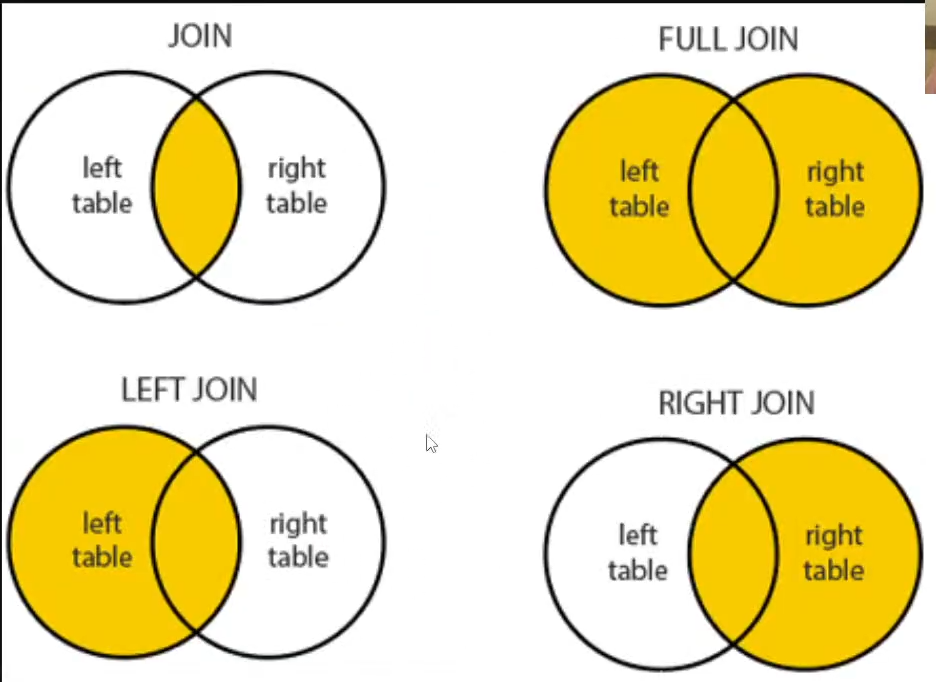

*Visual illustration of how inner, left, right, and outer joins differ.*

<a id="join-types-examples"></a>
## Join Types in Practice

Running the same `students.merge(registration, ...)` with `how='inner'`, `'left'`, `'right'`, and `'outer'` to see exactly how the result changes with each join type.

In [26]:
students.merge(registration,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,3,Parveen Bhalla,3,5
2,7,Tarun Thaker,9,8
3,7,Tarun Thaker,9,7
4,7,Tarun Thaker,9,2


In [27]:
# now left join
students.merge(registration,how='left',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1.0
1,2,Esha Butala,1,NaN
2,3,Parveen Bhalla,3,5.0
3,4,Marlo Dugal,14,NaN
4,5,Kusum Bahri,6,NaN
5,6,Lakshmi Contractor,10,NaN
6,7,Tarun Thaker,9,8.0
7,7,Tarun Thaker,9,7.0
8,7,Tarun Thaker,9,2.0
9,8,Radheshyam Dey,5,NaN


In [28]:
students.merge(registration,how='right',on='student_id')

,student_id,name,partner,course_id
0,23,NaN,NaN,1
1,15,NaN,NaN,5
2,18,NaN,NaN,6
3,23,NaN,NaN,4
4,16,NaN,NaN,9
5,18,NaN,NaN,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,NaN,NaN,3
9,3,Parveen Bhalla,3.0,5


In [ ]:
# outer join printout the all values of the left and right table
students.merge(registration,how='outer',on='student_id')
# this shows all the left and right table data

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,2,Esha Butala,1.0,NaN
2,3,Parveen Bhalla,3.0,5.0
3,4,Marlo Dugal,14.0,NaN
4,5,Kusum Bahri,6.0,NaN
5,6,Lakshmi Contractor,10.0,NaN
6,7,Tarun Thaker,9.0,8.0
7,7,Tarun Thaker,9.0,7.0
8,7,Tarun Thaker,9.0,2.0
9,8,Radheshyam Dey,5.0,NaN


<a id="merge-revenue-analysis"></a>
## Practical Merge Queries — Revenue & Enrollment Analysis

Using `merge()` across multiple tables to answer real business questions — total revenue, month-by-month revenue, a 3-table merge for course details, and a bar chart of enrollments per course.

In [38]:
# Total revenue generated by the company
revenue=registration.merge(courses,how='inner',on='course_id')['price'].sum()
print(f'{revenue} Pkr')

51082 Pkr


In [45]:
# month by month revenue generated
temp_df=multi_index.reset_index()
temp_df.merge(courses,how='inner',on='course_id').groupby('level_0')['price'].sum()

level_0
December    22391
November    28691
Name: price, dtype: int64

In [54]:
# print the name , course_name, price
# mean i will merge the 3 tables
students.merge(registration,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Kailash Harjo,python,2499
1,Parveen Bhalla,tableau,2499
2,Tarun Thaker,pandas,1099
3,Tarun Thaker,ms sxcel,1599
4,Tarun Thaker,sql,3499


<Axes: >

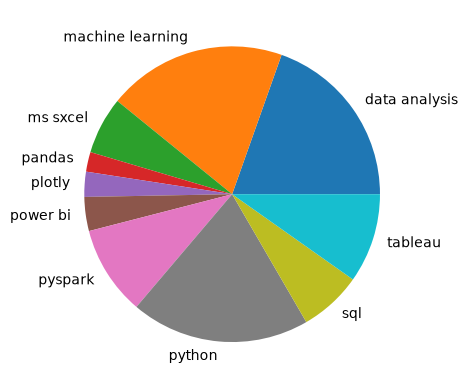

In [58]:
# make the bar chart for all courses
registration.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='pie')

<Axes: xlabel='course_name'>

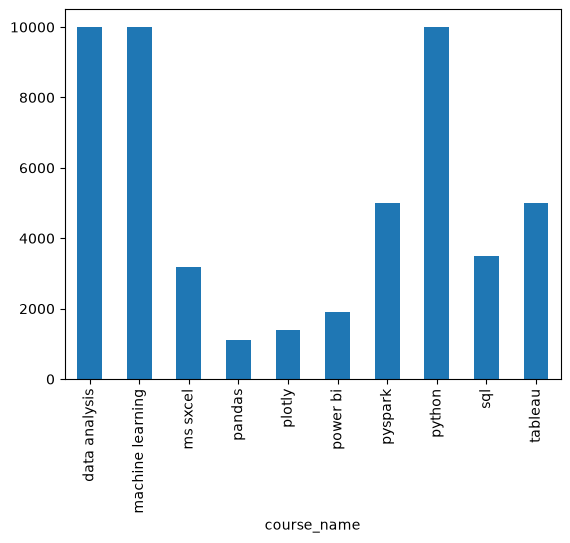

In [59]:
# make the bar chart for all courses
registration.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

<a id="set-operations"></a>
## Finding Common & Missing Records with NumPy Set Operations

Using `np.intersect1d()`, `np.setdiff1d()`, and `.isin()` to find students enrolled in both months, courses with zero enrollment, and students not enrolled in any course.

In [61]:
# get those students who enrolled in the both nov and dec month
common_students=np.intersect1d(nov_data['student_id'],dec_data['student_id'])
common_students

array([ 7, 16])

In [63]:
students[students['student_id'].isin(common_students)]

,student_id,name,partner
6,7,Tarun Thaker,9


In [65]:
# find course that got no enrollment
not_enrolled_course=np.setdiff1d(courses['course_id'],registration['course_id'])
not_enrolled_course

array([11, 12])

In [66]:
courses[courses['course_id'].isin(not_enrolled_course)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [67]:
# students who are not in any course
# same as above task
not_enrolled_course=np.setdiff1d(students['student_id'],registration['student_id'])
not_enrolled_course

array([ 2,  4,  5,  6,  8,  9, 10, 11])

In [69]:
students[students['student_id'].isin(not_enrolled_course)]

,student_id,name,partner
1,2,Esha Butala,1
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
10,11,David Mukhopadhyay,20


<a id="self-join"></a>
## Self Join

Merging the `students` table with itself to pair each student up with their partner, using `left_on`/`right_on`.

In [ ]:
# self join
# print student and its partner
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Esha Butala,Kailash Harjo
1,Parveen Bhalla,Parveen Bhalla
2,Kusum Bahri,Lakshmi Contractor
3,Lakshmi Contractor,Aayushman Sant
4,Tarun Thaker,Nitika Chatterjee
5,Radheshyam Dey,Kusum Bahri
6,Nitika Chatterjee,Marlo Dugal
7,Aayushman Sant,Radheshyam Dey


<a id="merge-groupby-queries"></a>
## Combining Merge with GroupBy — Real Queries

Chaining `merge()` with `groupby()` to answer bigger questions in one go — the top 3 students by number of registrations, who spent the most money overall, and merging all three tables together in a single chained call.

In [ ]:
# find  top 3 students who did the most registration
registration.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name          
7           Tarun Thaker      3
1           Kailash Harjo     1
3           Parveen Bhalla    1
Name: name, dtype: int64

In [ ]:
# find those students who spent most money on the courses
registration.merge(students,on='student_id').merge(courses,on='course_id').groupby(['name','price'])['price'].sum().sort_values(ascending=False).head(3)

name            price
Tarun Thaker    3499     3499
Kailash Harjo   2499     2499
Parveen Bhalla  2499     2499
Tarun Thaker    1599     1599
                1099     1099
Name: price, dtype: int64

In [14]:
# can also the syntax will be
pd.merge(registration,students,on='student_id').merge(courses,on='course_id').groupby(['name','price'])['price'].sum().sort_values(ascending=False).head(3)

name            price
Tarun Thaker    3499     3499
Kailash Harjo   2499     2499
Parveen Bhalla  2499     2499
Name: price, dtype: int64

---

[🔼 Back to Table of Contents](#top)

🎉 **End of Notes**
